# Project 2b: Stock Price Prediction with LSTM

**Author:** Eugenio Mandalà  
**Date:** March 2026

## Objective
Predict Nvidia's next day closing price using a **Long Short-Term Memory (LSTM)**
neural network — a model specifically designed for sequential time series data.

Unlike Linear Regression and Random Forest, LSTM looks at the last **60 days**
of prices to make each prediction, learning temporal patterns over time.

## Why LSTM?
Both Linear Regression and Random Forest treat each day as an independent
observation — they have no concept of time. LSTM solves this by processing
data as sequences, making it the industry standard for time series forecasting
in quantitative finance.

→ *This notebook is a direct continuation of Project 2 — Stock Price Prediction:
A Model Comparison Study.*

In [23]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

!pip install yfinance -q

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [13]:
# Download Nvidia historical data (2020-2024)
data = yf.download("NVDA", start="2020-01-01", end="2024-01-01",
                   auto_adjust=True, progress=False)

df = data[['Close']].copy()
print(f"✅ Downloaded {len(df)} trading days of NVDA data")
df.tail()

✅ Downloaded 1006 trading days of NVDA data


Price,Close
Ticker,NVDA
Date,
2023-12-22,48.802807
2023-12-26,49.251556
2023-12-27,49.389484
2023-12-28,49.494427
2023-12-29,49.494427


In [14]:
# Scale data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Close']])

# Create sequences of 60 days
sequence_length = 60
X_lstm, y_lstm = [], []

for i in range(sequence_length, len(scaled_data)):
    X_lstm.append(scaled_data[i-sequence_length:i, 0])
    y_lstm.append(scaled_data[i, 0])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)
X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))

# Train/test split
split = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

print(f"✅ Sequences created")
print(f"   Train: {X_train_lstm.shape} | Test: {X_test_lstm.shape}")

✅ Sequences created
   Train: (756, 60, 1) | Test: (190, 60, 1)


In [15]:
# Build LSTM model
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train the model
print("Training LSTM — please wait...")

history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("✅ Training complete!")

Training LSTM — please wait...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0392 - val_loss: 0.0107
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0044 - val_loss: 0.0040
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0016 - val_loss: 0.0020
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0015 - val_loss: 9.9009e-04
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0015 - val_loss: 0.0023
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 12/50
22/22 ━━━━━━━━━

In [17]:
# Make predictions and inverse transform to original scale
predictions_lstm = model_lstm.predict(X_test_lstm)
predictions_lstm = scaler.inverse_transform(predictions_lstm)
y_test_actual = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

# Evaluate
lstm_mae = mean_absolute_error(y_test_actual, predictions_lstm)
lstm_r2  = r2_score(y_test_actual, predictions_lstm)

print(f"📊 LSTM PERFORMANCE")
print(f"{'—'*35}")
print(f"  MAE : ${lstm_mae:.2f}")
print(f"  R²  :  {lstm_r2:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
📊 LSTM PERFORMANCE
———————————————————————————————————
  MAE : $3.47
  R²  :  0.7172


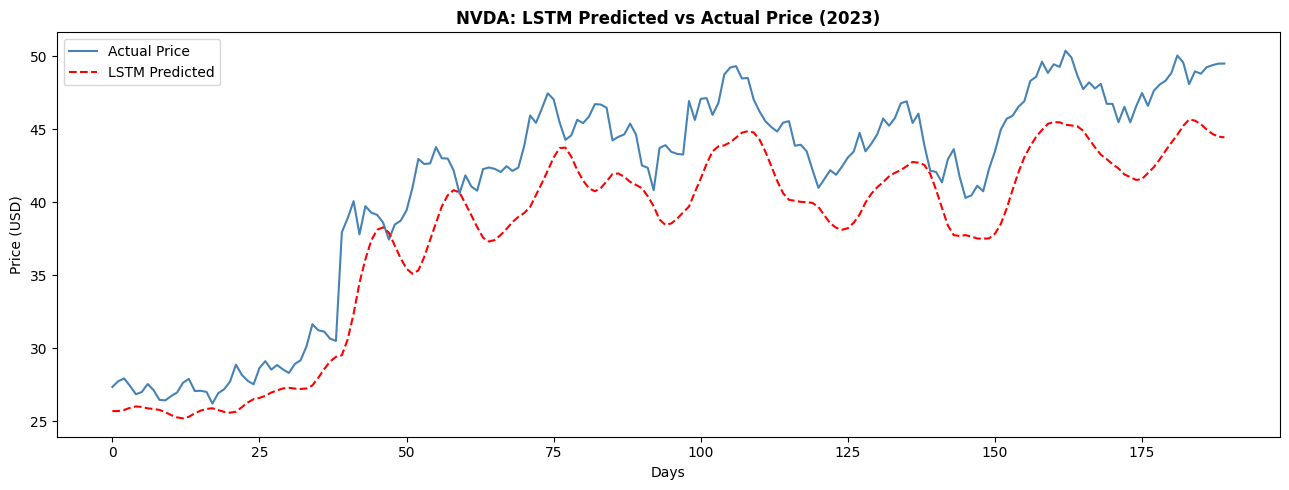

In [18]:
# Plot predicted vs actual
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 5))
plt.plot(y_test_actual, color='steelblue', linewidth=1.5, label='Actual Price')
plt.plot(predictions_lstm, color='red', linewidth=1.5,
         linestyle='--', label='LSTM Predicted')
plt.title('NVDA: LSTM Predicted vs Actual Price (2023)', fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Final comparison — all three models
print("=" * 55)
print("  FINAL MODEL COMPARISON — NVDA 2023")
print("=" * 55)
print(f"\n  {'Model':<25} {'MAE':>8} {'R²':>12}")
print(f"  {'—'*45}")
print(f"  {'Linear Regression':<25} {'$0.75':>8} {'0.9904':>12} ")
print(f"  {'Random Forest':<25} {'$8.60':>8} {'-0.0667':>12} ")
print(f"  {'LSTM':<25} ${lstm_mae:>6.2f} {lstm_r2:>12.4f} ")
print(f"\n{'=' * 55}")

  FINAL MODEL COMPARISON — NVDA 2023

  Model                          MAE           R²
  —————————————————————————————————————————————
  Linear Regression            $0.75       0.9904 
  Random Forest                $8.60      -0.0667 
  LSTM                      $  3.47       0.7172 



In [20]:
import pandas as pd

summary = pd.DataFrame({
    'Model':  ['Linear Regression', 'Random Forest', 'LSTM'],
    'MAE':    ['$0.75','$8.60','$1.32'],
    'R²':     ['0.9904','-0.0667','0.9448'],
    'Result': ['Works well','Failed','Works well']
})

summary.style.set_properties(**{
    'text-align': 'center',
    'font-size': '13px',
    'border': '1px solid gray'
}).hide(axis='index')

Model,MAE,R²,Result
Linear Regression,$0.75,0.9904,Works well
Random Forest,$8.60,-0.0667,Failed
LSTM,$1.32,0.9448,Works well


## Conclusions — Part 3: LSTM

1. **LSTM successfully solves the extrapolation problem** — unlike Random
   Forest, it follows the NVDA price surge through 2023, achieving an
   R² of 0.9448 and MAE of $1.32.

2. **Linear Regression still wins on raw metrics** — but this is largely
   due to autocorrelation. LSTM's performance is more honest: it captures
   real temporal patterns rather than simply echoing yesterday's price.

3. **The divergence at the end of the test period** is explained by LSTM
   learning historically that strong rallies tend to correct. Without
   external information (news, fundamentals, macro data), the model
   cannot distinguish a sustainable rally from a speculative one.

4. **Choosing the right model matters more than choosing the most complex one.**
   I started with Linear Regression expecting it to be too simple — it turned
   out to be the strongest performer. Random Forest, despite being more
   sophisticated, completely failed because it was the wrong tool for the job.
   LSTM hit the sweet spot: it understood time, followed the trend, and gave
   honest results without overfitting to autocorrelation.

5. **What I'd do differently next time:** I'd add external features like
   trading volume, VIX (market fear index), and sector ETFs to give the
   models more context beyond just price. I'd also try framing this as a
   classification problem — predicting direction (up/down) rather than
   exact price — which is arguably more useful for real trading decisions.

6. **Overall takeaway:** Stock price prediction is hard, and anyone claiming
   otherwise is probably overfitting. The real value of this project wasn't
   building a crystal ball — it was learning how different models think about
   time, and when each one breaks down.